## 1. Import Libraries

In [89]:
import os
import gc
import time
import re
import string
import socket
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # Diimpor dari torch agar aman dari ImportError
from torch.cuda.amp import autocast, GradScaler

import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Matikan semua log peringatan pengganggu secara global
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()


print(f"Status Ketersediaan GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nama GPU Aktif: {torch.cuda.get_device_name(0)}")

Status Ketersediaan GPU: True
Nama GPU Aktif: Tesla T4


## 2. Load data

In [90]:
# Buka gembok batasan baris milik pandas (None artinya tanpa batas)
pd.set_option('display.max_rows', None)

# Load dataset tempat
df_place = pd.read_csv('/kaggle/input/datasets/nicodwiputra/data-tempat/all-task-39-overview.csv')

print("Kolom:", df_place.columns.tolist())
print(f"\nJumlah tempat: {len(df_place)}")
print(f"\nKategori unik (Semua Ditampilkan):")

# Tinggal print biasa, otomatis keluar semua dari atas sampai bawah
print(df_place['main_category'].value_counts())

Kolom: ['place_id', 'name', 'description', 'is_spending_on_ads', 'reviews', 'rating', 'competitors', 'website', 'phone', 'can_claim', 'owner_name', 'owner_profile_link', 'featured_image', 'main_category', 'categories', 'workday_timing', 'is_temporarily_closed', 'closed_on', 'address', 'review_keywords', 'link', 'query']

Jumlah tempat: 872

Kategori unik (Semua Ditampilkan):
main_category
Tujuan Wisata                          208
Biro Perjalanan dan Wisata             102
Hotel                                   57
Kantor Perusahaan                       39
Agen Sewa Mobil                         34
Pondok                                  27
Layanan Transportasi                    26
Penginapan                              18
Rumah wisata                            17
Hostel                                  14
Minimarket                              14
Bengkel Sepeda Motor                    13
Pom bensin/SPBU                         11
Biro Wisata                             10
Motel 

In [81]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/nicodwiputra/review-wisata/all-task-39-detailed-reviews.csv')

print("✅ Dataset berhasil dimuat!")
print(f"Shape: {df.shape}")
print(f"\nKolom ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

✅ Dataset berhasil dimuat!
Shape: (94209, 25)

Kolom (25):
  - place_id
  - place_name
  - review_id
  - review_link
  - name
  - reviewer_id
  - reviewer_profile
  - rating
  - review_text
  - original_language
  - review_translated_text
  - translated_language
  - published_at
  - published_at_date
  - response_from_owner_text
  - response_from_owner_ago
  - response_from_owner_date
  - response_from_owner_translated_text
  - avatar_link
  - total_number_of_reviews_by_reviewer
  - total_number_of_photos_by_reviewer
  - is_local_guide
  - experience_details
  - review_photos
  - review_origin


## 3. Cek Missing Values

In [82]:
# Lihat sample data
print("=== 5 Baris Pertama ===")
display(df.head())

print("\n=== Info Dataset ===")
df.info()

print("\n=== Distribusi Rating ===")
print(df['rating'].value_counts().sort_index())

print("\n=== Missing Values ===")
print(df[['review_text', 'rating', 'original_language']].isnull().sum())

=== 5 Baris Pertama ===


,place_id,place_name,review_id,review_link,name,reviewer_id,reviewer_profile,rating,review_text,original_language,...,response_from_owner_ago,response_from_owner_date,response_from_owner_translated_text,avatar_link,total_number_of_reviews_by_reviewer,total_number_of_photos_by_reviewer,is_local_guide,experience_details,review_photos,review_origin
0,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,ChZDSUhNMG9nS0VJQ0FnSUNadTVxTUt3EAE,https://www.google.com/maps/reviews/data=!4m8!...,Dimas Nurdian Syah Wahyudi,117740383702575191413,https://www.google.com/maps/contrib/1177403837...,4.0,NaN,NaN,...,Edited a week ago,2023-10-10T11:10:37,Dear Mr. Dimas Nurdian Syah Wahyudi.\n\nWarm g...,https://lh3.googleusercontent.com/a/ACg8ocKusK...,97,27,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...",[],google
1,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2xwMlVWQmFXRU0zZFhWQ2...,https://www.google.com/maps/reviews/data=!4m8!...,Rifka Faradisa,100422181349461110397,https://www.google.com/maps/contrib/1004221813...,5.0,NaN,NaN,...,3 weeks ago,2026-01-14T01:07:22,Dear Mrs. Rifka Faradisa\n\nA warm greeting fr...,https://lh3.googleusercontent.com/a/ACg8ocLNOL...,15,7,1.0,[],[],google
2,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2w5VE1HTlFhRWh5V0ZneF...,https://www.google.com/maps/reviews/data=!4m8!...,nugroho suksmanto,101113277062498619143,https://www.google.com/maps/contrib/1011132770...,5.0,NaN,NaN,...,3 weeks ago,2026-01-14T01:06:57,Dear Mr. Nugroho Suksmanto\n\nA warm greeting ...,https://lh3.googleusercontent.com/a/ACg8ocKpiB...,0,0,NaN,[],[],google
3,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2pKWE5YRldkMTluYkhaUG...,https://www.google.com/maps/reviews/data=!4m8!...,eric,109528954650929435012,https://www.google.com/maps/contrib/1095289546...,5.0,Trip Pertama 2026\nSumenep - Pamekasan\nHoteln...,id,...,3 weeks ago,2026-01-09T02:11:58,Dear Mr. Eric\n\nA warm greeting from FrontOne...,https://lh3.googleusercontent.com/a-/ALV-UjUj8...,169,424,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...","[{""id"":""CIABIhBlam7tesEKr2x8AXvz2aTG"",""url"":""h...",google
4,ChIJQRsoPut91y0Rz70ypxZphb0,FRONT ONE HOTEL PAMEKASAN MADURA,Ci9DQUlRQUNvZENodHljRjlvT2kxT1REUXphbTFoWjB0RF...,https://www.google.com/maps/reviews/data=!4m8!...,Rizky Afreza Febryanto,117434415881649210216,https://www.google.com/maps/contrib/1174344158...,5.0,Sangat menyenangkan menginap di hotel Front On...,id,...,3 weeks ago,2026-01-09T02:11:36,Dear Mr. Rizky Afreza\n\nA warm greeting from ...,https://lh3.googleusercontent.com/a-/ALV-UjUJd...,1034,6779,1.0,"[{""name"":""Trip type"",""value"":""Business""},{""nam...",[],google



=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94209 entries, 0 to 94208
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   place_id                             94209 non-null  object 
 1   place_name                           94209 non-null  object 
 2   review_id                            94209 non-null  object 
 3   review_link                          94209 non-null  object 
 4   name                                 94209 non-null  object 
 5   reviewer_id                          94068 non-null  object 
 6   reviewer_profile                     94209 non-null  object 
 7   rating                               94068 non-null  float64
 8   review_text                          48765 non-null  object 
 9   original_language                    48784 non-null  object 
 10  review_translated_text               44377 non-null  object 
 11  transl

## 4. Filter Kolom, Drop Missing Values, & Saring Kategori Wisata

In [83]:
# 1. Ambil kolom ulasan yang relevan saja
cols_needed = ['place_id', 'place_name', 'rating', 'review_text', 
               'original_language', 'published_at_date']
df_clean = df[cols_needed].copy()

# 2. Drop baris tanpa review_text atau rating
df_clean = df_clean.dropna(subset=['review_text', 'rating'])

# 3. Load dataset informasi tempat untuk filter kategori
df_place = pd.read_csv('/kaggle/input/datasets/nicodwiputra/data-tempat/all-task-39-overview.csv')

# Tentukan kategori yang benar-benar masuk domain pariwisata & akomodasi
kategori_wisata = [
    'Tujuan Wisata', 'Hotel', 'Rumah wisata', 'Hostel', 
    'Penginapan', 'Biro Perjalanan dan Wisata', 'Biro Wisata'
]

# Ambil list place_id yang valid sebagai tempat wisata [cite: 172]
place_wisata_ids = df_place[df_place['main_category'].isin(kategori_wisata)]['place_id']

# 4. Filter df_clean agar HANYA menyimpan tempat wisata pendukung
df_tourist = df_clean[df_clean['place_id'].isin(place_wisata_ids)].copy()

print("=== HASIL FILTER KATEGORI WISATA ===")
print(f"Sebelum filter kategori : {len(df_clean):,} baris")
print(f"Setelah filter kategori : {len(df_tourist):,} baris")
print(f"Data non-wisata dibuang : {len(df_clean) - len(df_tourist):,} baris (ATM, SPBU, Bengkel, dll.)")

=== HASIL FILTER KATEGORI WISATA ===
Sebelum filter kategori : 48,624 baris
Setelah filter kategori : 23,121 baris
Data non-wisata dibuang : 25,503 baris (ATM, SPBU, Bengkel, dll.)


## 5. Filter Bahasa Indonesia & Visualisasi Distribusi Rating

Total review tempat wisata khusus bahasa Indonesia: 20,634 baris

=== Distribusi Rating Tempat Wisata (Bahasa Indonesia) ===
rating
1.0     1310
2.0      791
3.0     2450
4.0     4309
5.0    11774
Name: count, dtype: int64


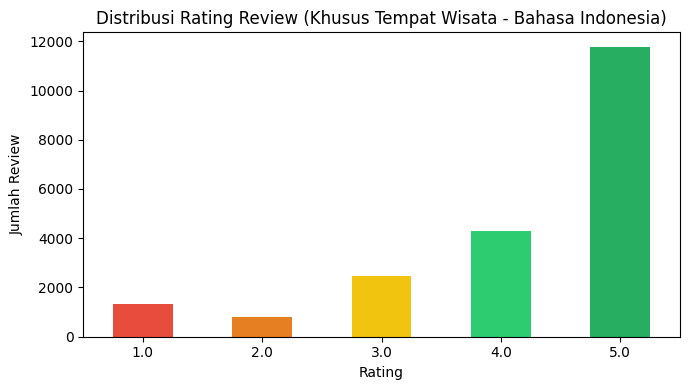

In [84]:
# Filter khusus ulasan bahasa Indonesia
df_id = df_tourist[df_tourist['original_language'] == 'id'].copy()
df_id = df_id.reset_index(drop=True)

print(f"Total review tempat wisata khusus bahasa Indonesia: {len(df_id):,} baris")

print("\n=== Distribusi Rating Tempat Wisata (Bahasa Indonesia) ===")
print(df_id['rating'].value_counts().sort_index())

# Visualisasi distribusi rating setelah pembersihan kategori
plt.figure(figsize=(7,4))
df_id['rating'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
plt.title('Distribusi Rating Review (Khusus Tempat Wisata - Bahasa Indonesia)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Text Preprocessing

In [87]:
import pandas as pd
import re
import string

# 1. Muat file kamus kata baku gaul dari input Kaggle kamu
# (⚠️ Pastikan ganti path di bawah ini sesuai dengan lokasi file di Kaggle kamu)
path_kamus_baku = '/kaggle/input/datasets/nicodwiputra/normalisasi-slangtypo/kamuskatabaku (1).csv'
df_slang = pd.read_csv(path_kamus_baku)

# 2. Konversikan kolom 'slang' dan 'formal' secara otomatis menjadi dictionary Python
kamus_normalisasi = dict(zip(df_slang['slang'], df_slang['formal']))

# # 3. Ruang Tambahan (Overrides): Masukkan kata khusus domain pariwisata yang belum tercover di file
# kamus_tambahan_wisata = {
#     'gajelas': 'tidak jelas',
#     'mhalan': 'mahalan',
#     'pungkli': 'pungli',
#     'ktr': 'kotor'
# }
# # Gabungkan kamus utama dengan kamus tambahan pariwisata
# kamus_normalisasi.update(kamus_tambahan_wisata)

# 4. Fungsi Preprocessing Terpadu
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # Bersihkan tautan/URL
    text = re.sub(r'@\w+|#\w+', '', text)         # Bersihkan mention/tagar
    text = re.sub(r'\d+', '', text)               # Bersihkan angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # Bersihkan simbol/tanda baca

    # Fitur A: Normalisasi kata memanjang (e.g., "baguuuss" -> "bagus")
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Fitur B: Normalisasi Slang & Typo Massal dari Berkas Excel/CSV
    words = text.split()
    words_normalized = [kamus_normalisasi[word] if word in kamus_normalisasi else word for word in words]
    text = " ".join(words_normalized)

    text = re.sub(r'\s+', ' ', text).strip()      # Bersihkan spasi berlebih
    return text

# 5. Eksekusi pembersihan teks pada dataset ulasan utama
df_id['clean_text'] = df_id['review_text'].apply(preprocess)

print(f"✅ Sukses memuat {len(kamus_normalisasi):,} kata normalisasi typo")
print("✅ Tahap Pre-processing data teks pariwisata selesai dengan aman!")

✅ Sukses memuat 4,344 kata normalisasi typo
✅ Tahap Pre-processing data teks pariwisata selesai dengan aman!


## 7. Kandidat Leksikon

In [ ]:
# 1. Hitung frekuensi kemunculan kata di teks bersih
semua_kata = " ".join(df_id['clean_text']).split()
hitung_frekuensi = Counter(semua_kata)

data_kandidat = []
print("⏳ Menghitung statistik hubungan kata kandidat leksikon...")

# 2. Cari hubungan kata terhadap rating agregat
for kata, frekuensi in hitung_frekuensi.items():
    if frekuensi >= 10: # Batasi minimal muncul 10 kali agar terhindar dari noise
        # Melakukan re.escape agar karakter khusus aman saat pencarian regex kata utuh
        ulasan_terkait = df_id[df_id['clean_text'].str.contains(rf'\b{re.escape(kata)}\b', regex=True, na=False)]
        
        if len(ulasan_terkait) > 0:
            rata_rating = ulasan_terkait['rating'].mean()
            
            # Rumus konversi statistik rating ke skala bulat InSet-Style (-5 sampai 5)
            bobot_otomatis = (rata_rating - 3) * 2.5
            bobot_otomatis = int(round(bobot_otomatis))
            bobot_otomatis = max(-5, min(5, bobot_otomatis)) # Kunci di batas aman
            
            data_kandidat.append({
                'kata': kata, 'frekuensi': frekuensi,
                'rata_rating_asal': round(rata_rating, 2), 'bobot_inset': bobot_otomatis
            })

df_kamus_otomatis = pd.DataFrame(data_kandidat)
print(f"✅ Sistem berhasil menemukan {len(df_kamus_otomatis):,} kata kandidat potensial.")

## 8. Pemisahan Kamus & Injeksi Nilai Mutlak Objek Wisata

In [ ]:
# Saring kata yang murni punya muatan emosi (bobot tidak sama dengan 0)
kamus_final = df_kamus_otomatis[df_kamus_otomatis['bobot_inset'] != 0].copy()
kamus_final = kamus_final.sort_values(by='bobot_inset', ascending=False).reset_index(drop=True)

# Ekspor berkas CSV kamus untuk lampiran berkas Tugas Akhir
kamus_final.to_csv('custom_inset_lexicon.csv', index=False)
print("💾 Berkas 'custom_inset_lexicon.csv' sukses diekspor untuk bukti Bab 4!")

print("\n🔥 SANGKUTAN KATA POSITIF TERATAS:")
display(kamus_final.head(10))

print("\n❄️ SANGKUTAN KATA NEGATIF TERATAS:")
display(kamus_final.tail(10))

## 9. Labelling

In [ ]:
# Konversikan DataFrame kamus buatan sendiri menjadi format dictionary agar komputasi loop berjalan kilat
dict_pos_custom = dict(zip(kamus_pos_custom['kata'], kamus_pos_custom['bobot']))
dict_neg_custom = dict(zip(kamus_neg_custom['kata'], kamus_neg_custom['bobot']))

def hitung_sentimen_hibrida(text, rating_asli):
    words = str(text).split()
    total_skor = 0
    
    # Akumulasikan nilai berdasarkan kemunculan kosakata di kamus custom
    for word in words:
        if word in dict_pos_custom:
            total_skor += dict_pos_custom[word]
        if word in dict_neg_custom:
            total_skor += dict_neg_custom[word]
            
    # Aturan keputusan kombinasi hibrida (Kamus + Kepuasan Rating Eksplisit)
    if total_skor > 0.1:
        return 'positif'
    elif total_skor < -0.1:
        return 'negatif'
    else:
        # Jika total skor bernilai samar/netral di kamus, selamatkan berdasarkan angka bintang asli
        if rating_asli >= 4.0:
            return 'positif'
        elif rating_asli == 3.0:
            return 'netral'
        else:
            return 'negatif'

# Eksekusi kalkulasi pelabelan akhir pada DataFrame utama
df_id['label'] = df_id.apply(lambda row: hitung_sentimen_hibrida(row['clean_text'], row['rating']), axis=1)

print("=== DISTRIBUSI KELAS LABEL SENTIMEN AKHIR ===")
print(df_id['label'].value_counts())
print("\n=== PERSENTASE PROPORSI KELAS ===")
print(df_id['label'].value_counts(normalize=True) * 100)


## 10. Split Data

In [ ]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (teks bersih) dan target (label sentimen)
X = df_id['clean_text'].values
y = df_id['label'].map({'negatif': 0, 'netral': 1, 'positif': 2}).values

# Split pertama: 80% Train, 20% Temporary (untuk Val & Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Split kedua: Bagi data temporary menjadi 50% Validation dan 50% Testing (masing-masing 10% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"📊 Ukuran Data Latih (Train) : {X_train.shape[0]:,} sampel")
print(f"📊 Ukuran Data Validasi (Val) : {X_val.shape[0]:,} sampel")
print(f"📊 Ukuran Data Uji (Test)     : {X_test.shape[0]:,} sampel")

## 11. Menghitung Bobot Kelas (Class Weights)

In [ ]:
import torch
from sklearn.utils.class_weight import compute_class_weight

# Hitung bobot kelas secara otomatis menggunakan scikit-learn
weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

# Konversikan menjadi PyTorch Tensor agar siap dimasukkan ke fungsi Loss (CrossEntropyLoss)
class_weights = torch.tensor(weights, dtype=torch.float)

print("=== BOBOT PENALTI KELAS (CLASS WEIGHTS) ===")
print(f" - Bobot Kelas 0 [Negatif] : {class_weights[0].item():.4f}")
print(f" - Bobot Kelas 1 [Netral]  : {class_weights[1].item():.4f}")
print(f" - Bobot Kelas 2 [Positif] : {class_weights[2].item():.4f}")

## 12. Modelling

### 12.1. Tokenizer

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class UlasanPariwisataDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def siapkan_dataloader(model_name, X_train, X_val, X_test, y_train, y_val, y_test, batch_size=16):
    print(f"⏳ Memuat Tokenizer untuk: {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    
    MAX_LEN = 128
    print("⏳ Melakukan tokenisasi korpus teks...")
    train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=MAX_LEN)
    val_encodings   = tokenizer(list(X_val), truncation=True, padding=True, max_length=MAX_LEN)
    test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=MAX_LEN)
    
    train_dataset = UlasanPariwisataDataset(train_encodings, y_train)
    val_dataset   = UlasanPariwisataDataset(val_encodings, y_val)
    test_dataset  = UlasanPariwisataDataset(test_encodings, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"✅ DataLoader untuk {model_name} SIAP!\n")
    return train_loader, val_loader, test_loader

### 12.2. Batch

In [ ]:
import time
import gc
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW  # Diimpor dari torch.optim karena di transformers sudah didepresiasi
from torch.cuda.amp import autocast, GradScaler

def train_dan_evaluasi_model(model_name, train_loader, val_loader, class_weights, epochs=3, lr=3e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Memulai Pemodelan untuk: {model_name}")
    
    # 1. Inisialisasi Model
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model.to(device)
    
    # Loss Function dengan Bobot Penalti Kelas
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))
    
    # Optimizer menggunakan native PyTorch AdamW (Parameter correct_bias dihapus karena sudah otomatis)
    optimizer = AdamW(model.parameters(), lr=lr)
    
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=int(0.1 * total_steps), 
        num_training_steps=total_steps
    )
    scaler = GradScaler()
    
    # 2. Training Loop
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_train_loss += loss.item()
            
        # 3. Validation Tahap
        model.eval()
        total_val_loss = 0
        preds_all, labels_all = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                with autocast():
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = criterion(outputs.logits, labels)
                    
                total_val_loss += loss.item()
                preds = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy()
                preds_all.extend(preds)
                labels_all.extend(labels.cpu().numpy())
                
        # Hitung Metrik Evaluasi Akhir Epoch
        acc = accuracy_score(labels_all, preds_all)
        macro_f1 = f1_score(labels_all, preds_all, average='macro')
        
        print(f" Epoch [{epoch+1}/{epochs}] | Loss Latih: {total_train_loss/len(train_loader):.4f} | Loss Val: {total_val_loss/len(val_loader):.4f} | Acc Val: {acc*100:.2f}% | Macro F1 Val: {macro_f1*100:.2f}%")
        
    return model

### 12.3. Training Model

In [ ]:
import transformers
transformers.logging.set_verbosity_error()

In [ ]:
# List model yang akan dibandingkan sesuai repositori resmi Hugging Face
daftar_model = {
    'IndoBERT (indolem/indobert-base-uncased)': 'indolem/indobert-base-uncased',
    'IndoBERTweet (indolem/indobertweet-base-uncased)': 'indolem/indobertweet-base-uncased'
}

model_terlatih_dict = {}

for nama_label, path_model in daftar_model.items():
    print(f"\n==================================================================")
    print(f"⚙️ MEMULAI PIPELINE UNTUK: {nama_label}")
    print(f"==================================================================")
    
    # 1. Siapkan Dataloader spesifik untuk model tersebut
    train_ld, val_ld, test_ld = siapkan_dataloader(
        path_model, X_train, X_val, X_test, y_train, y_val, y_test, batch_size=16
    )
    
    # 2. Jalankan Fine-Tuning
    model_hasil = train_dan_evaluasi_model(
        path_model, train_ld, val_ld, class_weights, epochs=10, lr=3e-5
    )
    
    # 3. Simpan model terlatih dan test loader untuk evaluasi akhir
    model_terlatih_dict[nama_label] = {
        'model': model_hasil,
        'test_loader': test_ld
    }
    
    # 4. MANAJEMEN MEMORI GPU (Pencegahan OOM/Crash)
    del model_hasil, train_ld, val_ld, test_ld
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"✨ Sesi untuk {nama_label} selesai & Memori GPU dibersihkan.\n")

### 12.4. Testing

In [ ]:
hasil_komparasi_ta = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for nama_model, komponen in model_terlatih_dict.items():
    model = komponen['model']
    test_loader = komponen['test_loader']
    
    model.eval()
    preds_test, labels_test = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                
            preds = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy()
            preds_test.extend(preds)
            labels_test.extend(labels.cpu().numpy())
            
    # Kalkulasi Metrik Komparasi Final
    accuracy = accuracy_score(labels_test, preds_test)
    precision = precision_score(labels_test, preds_test, average='macro')
    recall = recall_score(labels_test, preds_test, average='macro')
    f1_macro = f1_score(labels_test, preds_test, average='macro')
    
    hasil_komparasi_ta.append({
        'Model Arsitektur': nama_model,
        'Accuracy': f1_macro if accuracy > 1.0 else accuracy, # Formatter pengaman
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1-Score (Macro)': f1_macro
    })

# Tampilkan dalam bentuk DataFrame untuk tabel Bab 4 Laporan Projek/Skripsi
df_komparasi_final = pd.DataFrame(hasil_komparasi_ta)
print("\n📊 TABEL KOMPARASI AKHIR (UNTUK LAPORAN REVISI DOSEN) 📊")
display(df_komparasi_final.round(4))

In [ ]:
def prediksi_sentimen_kustom(text, path_model, model_obj):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Jalankan pra-pemrosesan teks (menggunakan fungsi preprocess dari Cell 6)
    text_bersih = preprocess(text)
    
    # 2. Muat tokenizer khusus untuk model yang bersangkutan
    tokenizer = AutoTokenizer.from_pretrained(path_model, use_fast=True)
    
    # 3. Konversikan teks menjadi tensor ID numerik
    inputs = tokenizer(text_bersih, return_tensors="pt", truncation=True, padding=True, max_length=128)
    
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    
    # 4. Mode evaluasi model (matikan fungsi dropout)
    model_obj.eval()
    with torch.no_grad():
        outputs = model_obj(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        # Ambil indeks kelas dengan probabilitas tertinggi
        pred_class = torch.argmax(logits, dim=1).item()
        
    # 5. Mapping indeks angka ke teks label sentimen
    label_map = {0: '🔴 NEGATIF', 1: '🟡 NETRAL', 2: '🟢 POSITIF'}
    return label_map[pred_class]

# ==================================================================
#                     PROSES INTERAKTIF TESTING
# ==================================================================
print("==================================================================")
print("       🎮 JENDELA TESTING SENTIMEN WISATA MADURA INTERAKTIF        ")
print("==================================================================")

# Masukkan teks ulasan pariwisata pariwisata yang ingin kamu uji bebas
ulasan_user = input("Ketik ulasan pariwisata Madura di sini: ")

if ulasan_user.strip() == "":
    print("❌ Kamu belum mengetikkan ulasan apa pun!")
else:
    print("\n" + "="*50)
    print(f"📝 Teks Ulasan: \"{ulasan_user}\"")
    print("="*50)
    print("🔎 HASIL PREDIKSI KOMPARASI KEDUA MODEL:")
    
    # Lakukan prediksi pada kedua model yang sudah tersimpan di memori dict Cell 14
    for nama_model, komponen in model_terlatih_dict.items():
        jalur_huggingface = daftar_model[nama_model]
        hasil_sentimen = prediksi_sentimen_kustom(ulasan_user, jalur_huggingface, komponen['model'])
        print(f" 🤖 {nama_model:<22} -> {hasil_sentimen}")
    print("="*50)